In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
data = pd.read_csv("Apple_daily.csv")
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1986-09-22 00:00:00-04:00,0.114334,0.120733,0.114334,0.120307,239680000,0.0,0.0
1,1986-09-23 00:00:00-04:00,0.120307,0.123719,0.119880,0.123293,338240000,0.0,0.0
2,1986-09-24 00:00:00-04:00,0.123293,0.124146,0.116041,0.119880,176870400,0.0,0.0
3,1986-09-25 00:00:00-04:00,0.119880,0.120307,0.114761,0.117747,187801600,0.0,0.0
4,1986-09-26 00:00:00-04:00,0.116467,0.117321,0.115614,0.116894,70022400,0.0,0.0


In [3]:
data["Date"] = pd.to_datetime(data["Date"], utc=True).dt.tz_convert(None)
data = data.sort_values("Date").reset_index(drop=True)

print("Data loaded successfully")
print("Rows:", len(data))
print("Columns:", len(data.columns))

Data loaded successfully
Rows: 10070
Columns: 8


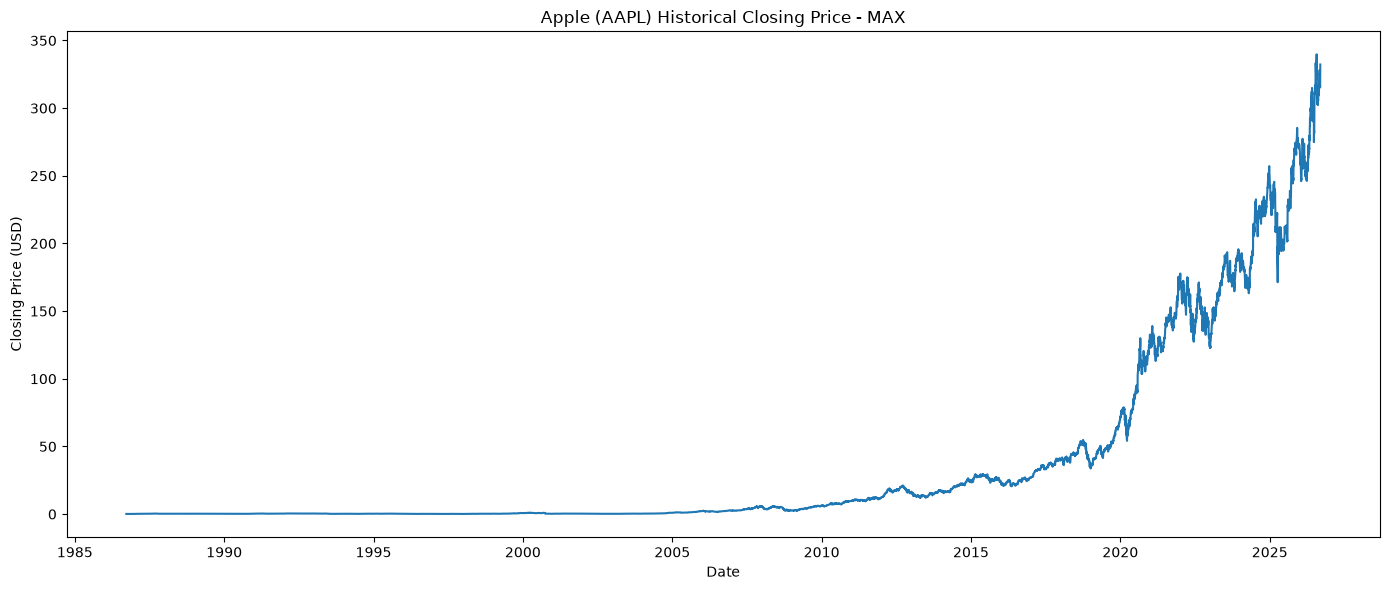

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Close"])
plt.title("Apple (AAPL) Historical Closing Price - MAX")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.tight_layout()
plt.show()

In [5]:
print("First 5 rows:")
data.head()

First 5 rows:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1986-09-22 04:00:00,0.114334,0.120733,0.114334,0.120307,239680000,0.0,0.0
1,1986-09-23 04:00:00,0.120307,0.123719,0.119880,0.123293,338240000,0.0,0.0
2,1986-09-24 04:00:00,0.123293,0.124146,0.116041,0.119880,176870400,0.0,0.0
3,1986-09-25 04:00:00,0.119880,0.120307,0.114761,0.117747,187801600,0.0,0.0
4,1986-09-26 04:00:00,0.116467,0.117321,0.115614,0.116894,70022400,0.0,0.0


In [6]:
print("Last 5 rows:")
data.tail()

Last 5 rows:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
10065,2026-09-04 04:00:00,328.309998,328.929993,317.859985,319.970001,39606900,0.0,0.0
10066,2026-09-08 04:00:00,317.100006,320.700012,314.899994,316.220001,35477100,0.0,0.0
10067,2026-09-09 04:00:00,315.489990,319.149994,309.899994,315.339996,65640000,0.0,0.0
10068,2026-09-10 04:00:00,316.670013,326.739990,316.510010,326.570007,70011900,0.0,0.0
10069,2026-09-11 04:00:00,327.450012,336.220001,326.299988,332.269989,50659000,0.0,0.0


In [7]:
print("Missing values:")
print(data.isnull().sum())
print("\nDuplicate rows:", data.duplicated().sum())
print("Duplicate dates:", data["Date"].duplicated().sum())

Missing values:
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Duplicate rows: 0
Duplicate dates: 0


In [8]:
data.describe()
print("Mean closing price:", data["Close"].mean())
print("Median closing price:", data["Close"].median())
print("Minimum closing price:", data["Close"].min())
print("Maximum closing price:", data["Close"].max())
print("\nStart date:", data["Date"].min())
print("End date:", data["Date"].max())

Mean closing price: 36.374435249168535
Median closing price: 2.2342487573623657
Minimum closing price: 0.0967386290431022
Maximum closing price: 339.78692626953125

Start date: 1986-09-22 04:00:00
End date: 2026-09-11 04:00:00


In [9]:
print("Dates in correct order:", data["Date"].is_monotonic_increasing)
print("Negative closing prices:", (data["Close"] < 0).sum())

wrong_rows = (
    (data["High"] < data["Open"]) |
    (data["High"] < data["Close"]) |
    (data["High"] < data["Low"]) |
    (data["Low"] > data["Open"]) |
    (data["Low"] > data["Close"])
)

print("Incorrect OHLC rows:", wrong_rows.sum())

Dates in correct order: True
Negative closing prices: 0
Incorrect OHLC rows: 0


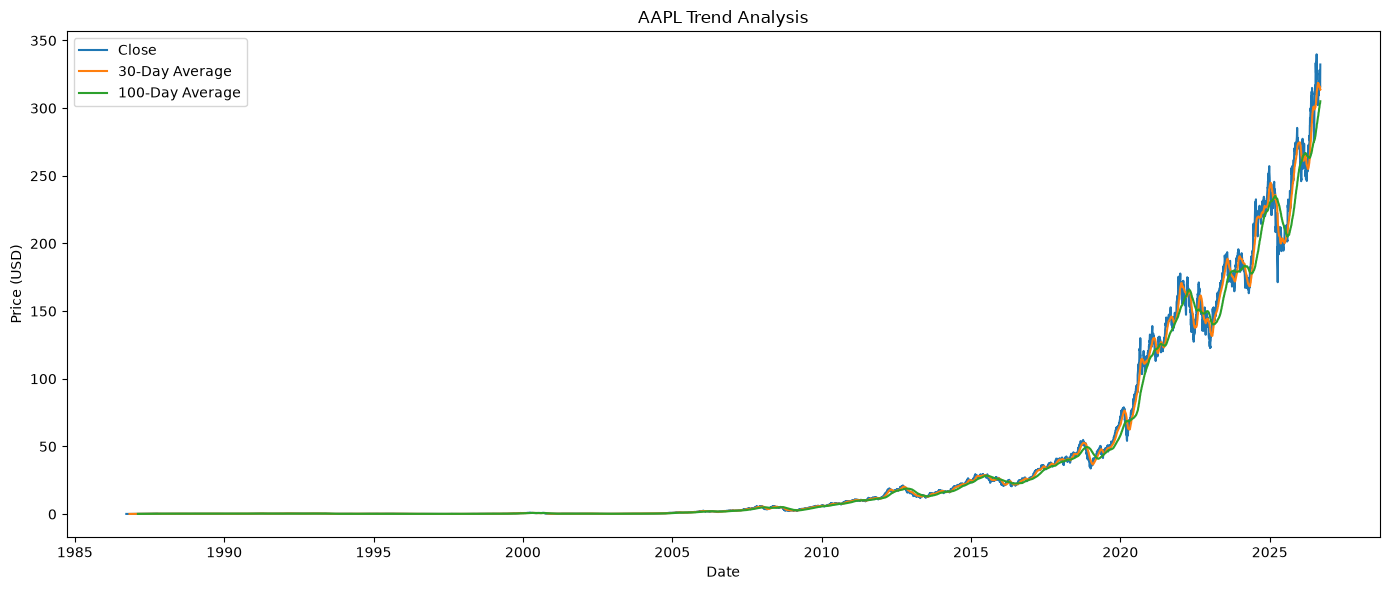

In [10]:
data["MA30"] = data["Close"].rolling(30).mean()
data["MA100"] = data["Close"].rolling(100).mean()

plt.figure(figsize=(14, 6))
plt.plot(data["Date"], data["Close"], label="Close")
plt.plot(data["Date"], data["MA30"], label="30-Day Average")
plt.plot(data["Date"], data["MA100"], label="100-Day Average")
plt.title("AAPL Trend Analysis")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

                 Date     Close  Daily_Return
0 1986-09-22 04:00:00  0.120307           NaN
1 1986-09-23 04:00:00  0.123293      0.024821
2 1986-09-24 04:00:00  0.119880     -0.027680
3 1986-09-25 04:00:00  0.117747     -0.017792
4 1986-09-26 04:00:00  0.116894     -0.007246


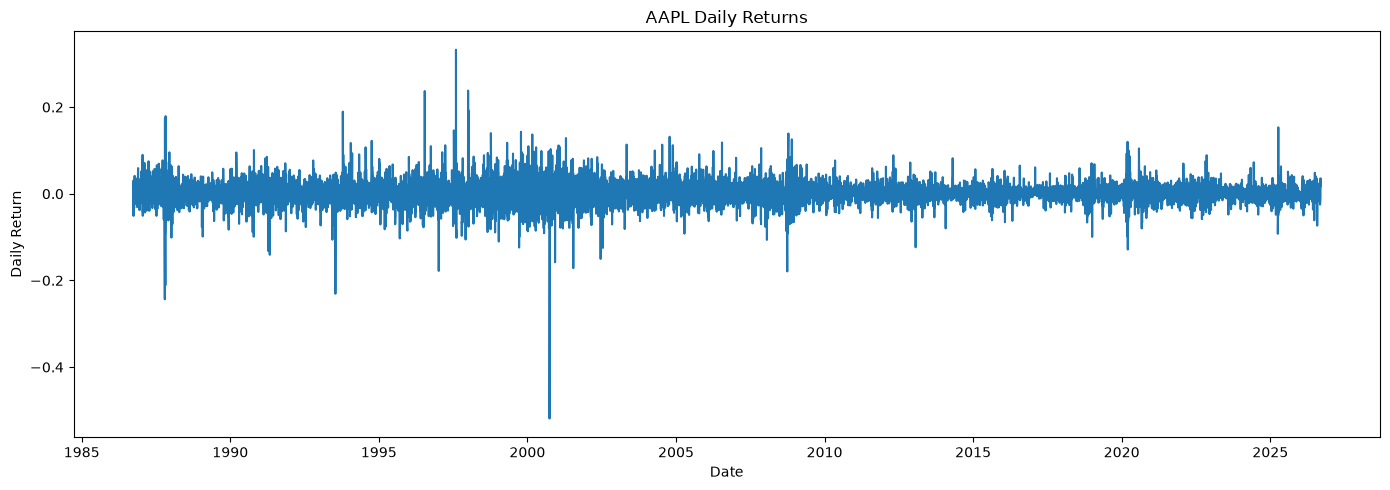

In [12]:
data["Daily_Return"] = data["Close"].pct_change()
print(data[["Date", "Close", "Daily_Return"]].head())
plt.figure(figsize=(14, 5))
plt.plot(data["Date"], data["Daily_Return"])
plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.tight_layout()
plt.show()

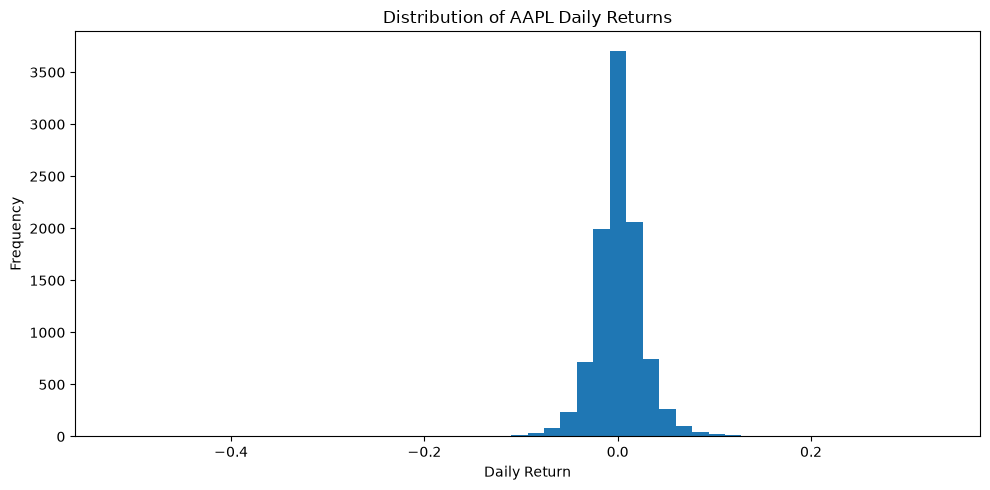

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(data["Daily_Return"].dropna(), bins=50)
plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Month
1     0.177555
2     0.108268
3     0.154035
4     0.149202
5     0.101844
6    -0.050361
7     0.244273
8     0.242047
9    -0.137398
10    0.226559
11    0.139126
12    0.004201
Name: Daily_Return, dtype: float64


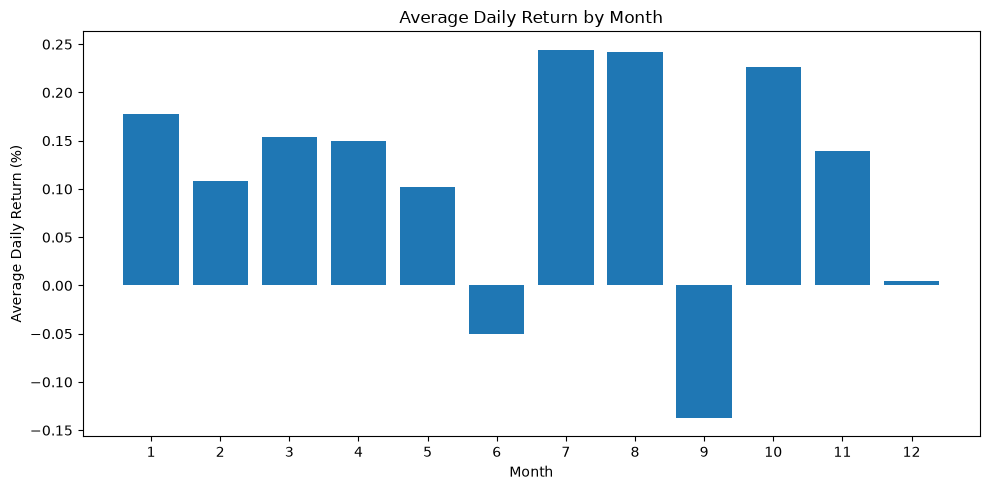

In [14]:
data["Month"] = data["Date"].dt.month
monthly_returns = data.groupby("Month")["Daily_Return"].mean() * 100
print(monthly_returns)
plt.figure(figsize=(10, 5))
plt.bar(monthly_returns.index, monthly_returns.values)
plt.title("Average Daily Return by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Return (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Day
Monday       0.206789
Tuesday      0.119832
Wednesday    0.204745
Thursday     0.079404
Friday      -0.033002
Name: Daily_Return, dtype: float64


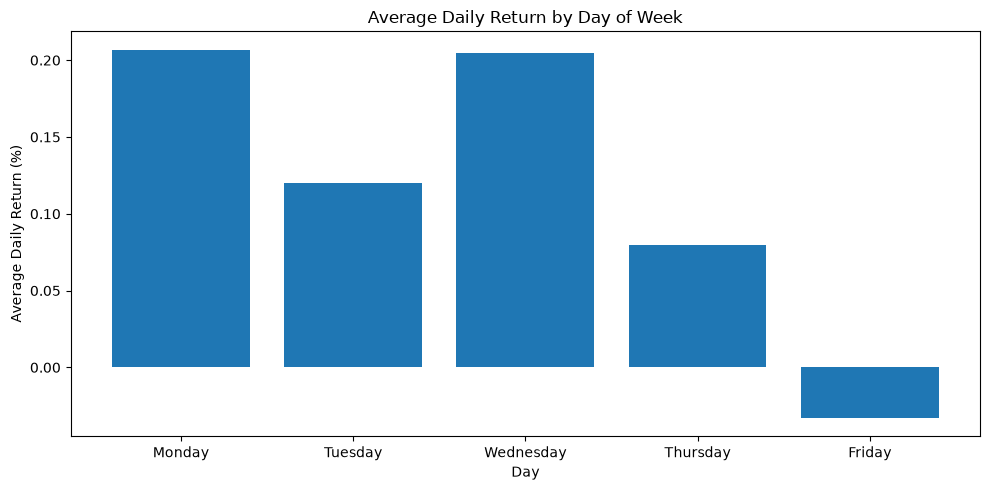

In [15]:
data["Day"] = data["Date"].dt.day_name()
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
day_returns = data.groupby("Day")["Daily_Return"].mean() * 100
day_returns = day_returns.reindex(days)
print(day_returns)
plt.figure(figsize=(10, 5))
plt.bar(day_returns.index, day_returns.values)
plt.title("Average Daily Return by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Daily Return (%)")
plt.tight_layout()
plt.show()

In [16]:
data["Year"] = data["Date"].dt.year

yearly = data.groupby("Year").agg(
    Average_Close=("Close", "mean"),
    Maximum_Close=("Close", "max"),
    Minimum_Close=("Close", "min"),
    Average_Volume=("Volume", "mean")
)

yearly

,Average_Close,Maximum_Close,Minimum_Close,Average_Volume
Year,,,,
1986,0.126346,0.149317,0.110921,2.021849e+08
1987,0.266371,0.405575,0.139505,2.362502e+08
1988,0.286092,0.325420,0.249927,1.632134e+08
1989,0.289655,0.345026,0.234139,2.020072e+08
1990,0.263995,0.332965,0.176238,1.755017e+08
1991,0.372945,0.515651,0.292240,2.266706e+08
1992,0.392759,0.499791,0.310807,1.619603e+08
1993,0.296713,0.468103,0.164353,2.231341e+08
1994,0.250333,0.318789,0.184553,2.268091e+08


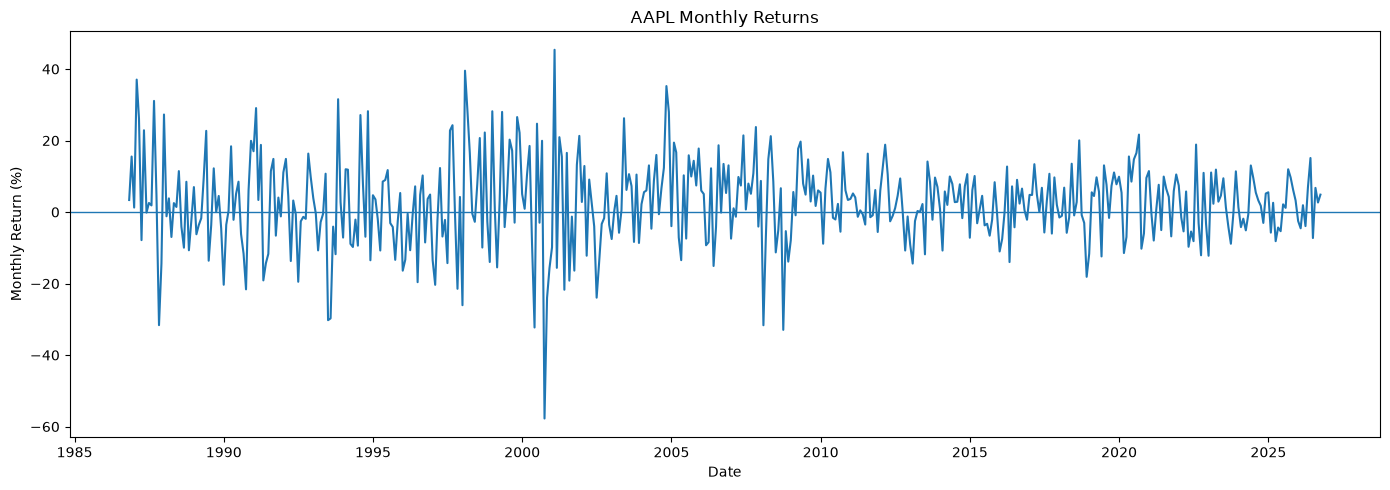

In [17]:
monthly_price = data.set_index("Date")["Close"].resample("ME").last()
monthly_change = monthly_price.pct_change().dropna() * 100

plt.figure(figsize=(14, 5))
plt.plot(monthly_change.index, monthly_change)
plt.axhline(0, linewidth=1)
plt.title("AAPL Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return (%)")
plt.tight_layout()
plt.show()

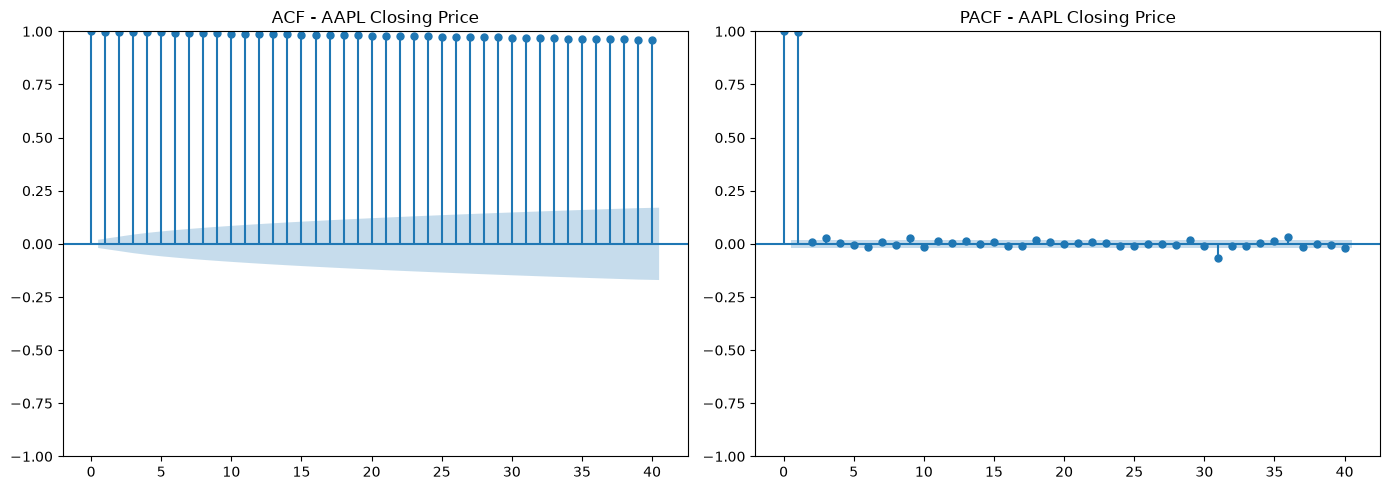

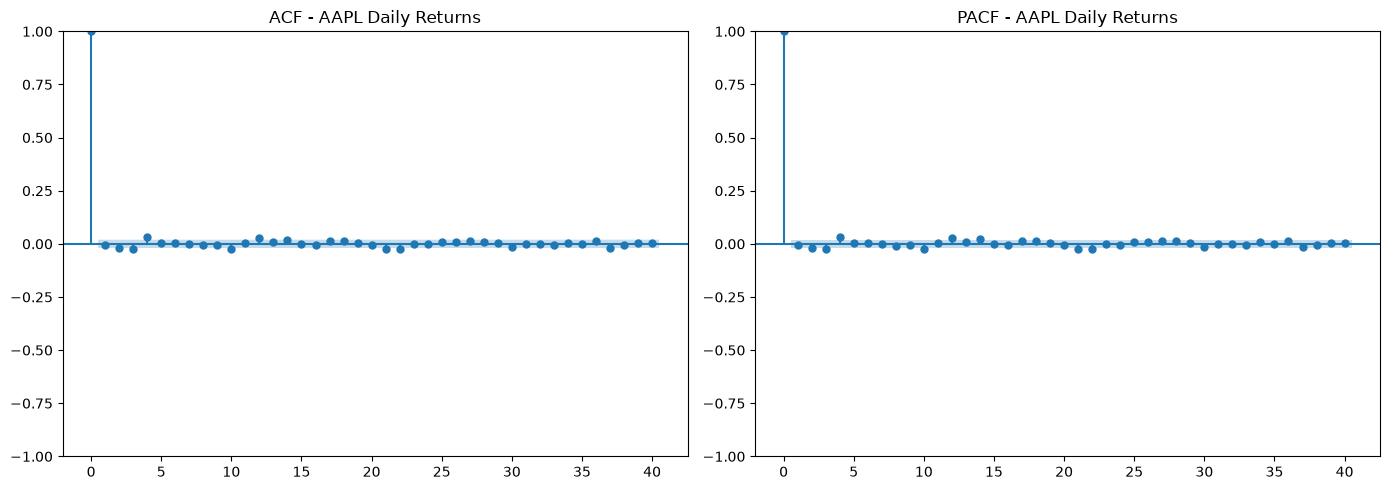

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(data["Close"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF - AAPL Closing Price")
plot_pacf(data["Close"].dropna(), lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF - AAPL Closing Price")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(data["Daily_Return"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF - AAPL Daily Returns")
plot_pacf(data["Daily_Return"].dropna(), lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF - AAPL Daily Returns")
plt.tight_layout()
plt.show()

In [19]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("Conclusion: Stationary")
    else:
        print("Conclusion: Non-stationary")
    print()

adf_test(data["Close"], "AAPL Closing Price")
adf_test(data["Daily_Return"], "AAPL Daily Returns")

/tmp/ipykernel_4998/260111845.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


AAPL Closing Price
ADF statistic: 4.800854020012458
p-value: 1.0
Conclusion: Non-stationary

AAPL Daily Returns
ADF statistic: -49.96406561266139
p-value: 0.0
Conclusion: Stationary



/tmp/ipykernel_4998/260111845.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


In [20]:
n = len(data)
train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train = data.iloc[:train_end].copy()
validation = data.iloc[train_end:validation_end].copy()
test = data.iloc[validation_end:].copy()

print("Train rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))
print("\nTrain:", train["Date"].min(), "to", train["Date"].max())
print("Validation:", validation["Date"].min(), "to", validation["Date"].max())
print("Test:", test["Date"].min(), "to", test["Date"].max())

Train rows: 7049
Validation rows: 1510
Test rows: 1511

Train: 1986-09-22 04:00:00 to 2014-09-05 04:00:00
Validation: 2014-09-08 04:00:00 to 2020-09-03 04:00:00
Test: 2020-09-04 04:00:00 to 2026-09-11 04:00:00


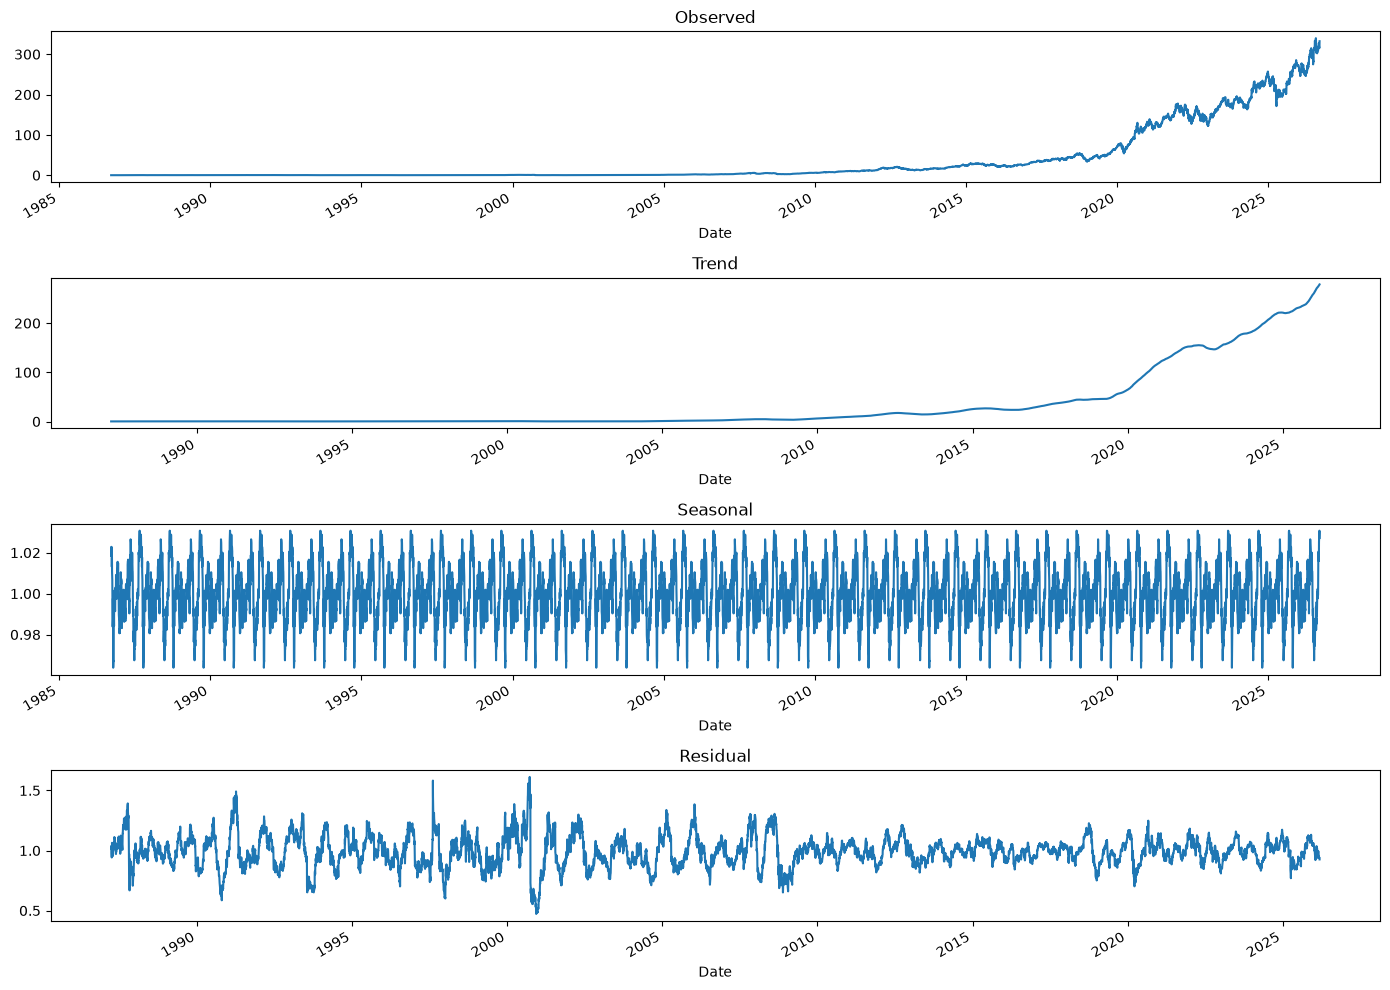

In [23]:
print("Skewness:", data["Daily_Return"].skew())
print("Kurtosis:", data["Daily_Return"].kurtosis())

Skewness: -0.39609696941463
Kurtosis: 23.099365711092577


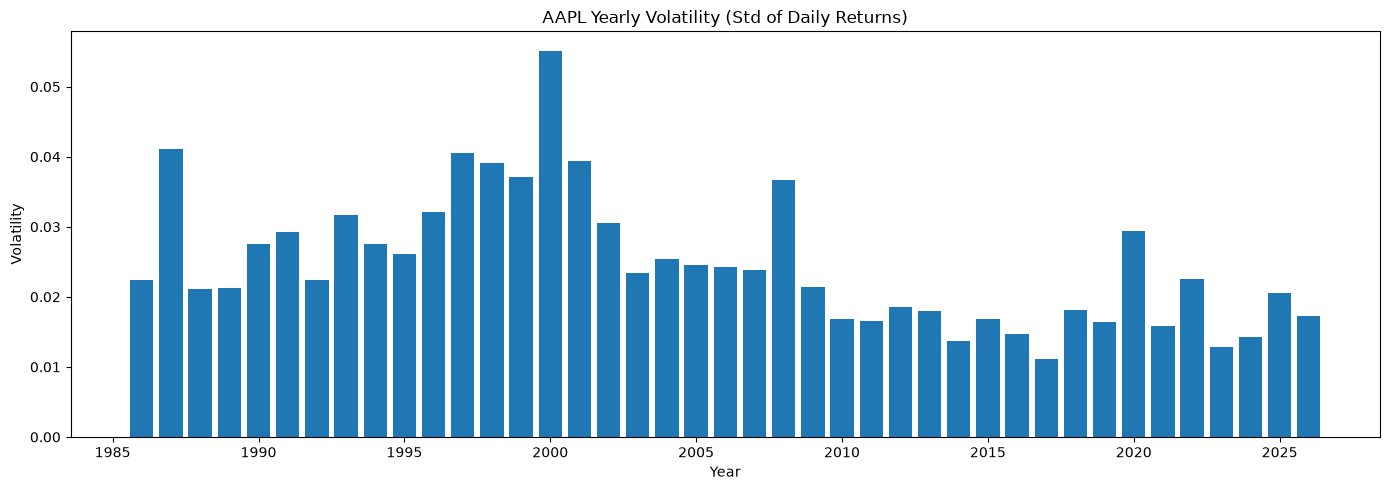

In [24]:
yearly_volatility = data.groupby("Year")["Daily_Return"].std()

plt.figure(figsize=(14, 5))
plt.bar(yearly_volatility.index, yearly_volatility.values)
plt.title("AAPL Yearly Volatility (Std of Daily Returns)")
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

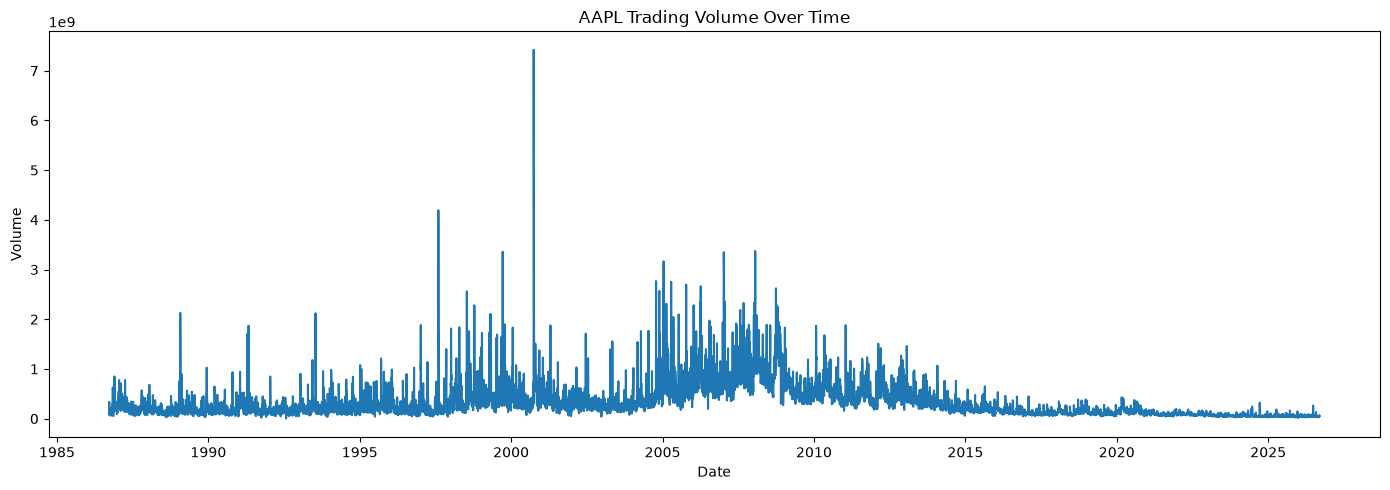

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(data["Date"], data["Volume"])
plt.title("AAPL Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()